# DDM Rankings: Naive vs Sentence-Length-Standardized

This notebook computes **naive vs sentence-length-standardized DDM (Dependency Distance Minimization) rankings** across UD treebanks. It measures rank agreement via Spearman ρ, Cohen's d, and runs sensitivity analysis with alternative reference distributions.

**Key findings (full dataset, 314 treebanks):** Spearman ρ=0.676, Cohen's d=1.046, mean |rank shift|=52.7

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# psutil, loguru — NOT on Colab, always install
_pip('psutil', 'loguru')

# Core packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
from collections import defaultdict

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## Load Data

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-3bc3de-sentence-length-standardization-reveals-/main/experiment_iter2_ddm_rankings/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
dataset = load_data()
ref_dist = {int(k): v for k, v in dataset["metadata"]["reference_distribution"].items()}
print(f"Loaded dataset with {len(dataset['datasets'][0]['examples'])} treebanks")

Loaded dataset with 30 treebanks


## Parse Treebanks and Compute Rankings

In [5]:
def parse_treebanks(dataset):
    """Extract treebank summaries into flat records."""
    ds = next(d for d in dataset["datasets"] if d["dataset"] == "ud_treebank_summaries")
    records = []
    for ex in ds["examples"]:
        inp = json.loads(ex["input"])
        out = json.loads(ex["output"])
        rec = {
            "treebank_id": inp["treebank_id"],
            "language_family": inp.get("language_family"),
            "word_order": inp.get("word_order"),
            "case_richness": inp.get("case_richness", 0) or 0,
            "n_sentences": inp.get("n_sentences", 0),
            "mean_sentence_length": inp.get("mean_sentence_length", 0),
            "naive_ddm": out["naive_ddm"],
            "standardized_ddm": out["standardized_ddm"],
            "ddm_by_length": {int(k): v for k, v in out.get("ddm_by_length", {}).items()},
            "sentence_length_distribution": {
                int(k): v for k, v in out.get("sentence_length_distribution", {}).items()
            },
        }
        records.append(rec)
    return records

def rank_descending(values):
    """Rank values descending (highest = rank 1). Uses average for ties."""
    return stats.rankdata(-values, method="average")

records = parse_treebanks(dataset)
n = len(records)

naive_vals = np.array([r["naive_ddm"] for r in records])
std_vals = np.array([r["standardized_ddm"] for r in records])
naive_ranks = rank_descending(naive_vals)
std_ranks = rank_descending(std_vals)

print(f"Parsed {n} treebank records")
print(f"Naive DDM range: [{naive_vals.min():.4f}, {naive_vals.max():.4f}]")
print(f"Std DDM range:   [{std_vals.min():.4f}, {std_vals.max():.4f}]")

Parsed 30 treebank records
Naive DDM range: [0.0225, 0.6592]
Std DDM range:   [0.0124, 0.4694]


## Primary Metrics: Spearman ρ, Cohen's d, Rank Shifts

In [6]:
rho, rho_p = stats.spearmanr(naive_ranks, std_ranks)
rank_shifts = std_ranks - naive_ranks
abs_shifts = np.abs(rank_shifts)
mean_abs_shift = float(np.mean(abs_shifts))
max_shift = float(np.max(abs_shifts))
cohens_d = float(np.mean(abs_shifts) / np.std(abs_shifts)) if np.std(abs_shifts) > 0 else 0.0

print(f"Spearman ρ = {rho:.4f} (p = {rho_p:.2e})")
print(f"Mean |rank shift| = {mean_abs_shift:.1f}, Max = {max_shift:.1f}")
print(f"Cohen's d (|shifts|) = {cohens_d:.4f}")

Spearman ρ = 0.8514 (p = 2.47e-09)
Mean |rank shift| = 3.7, Max = 12.0
Cohen's d (|shifts|) = 1.2345


## Language Family Shift Analysis

In [7]:
family_data = defaultdict(list)
for i, rec in enumerate(records):
    fam = rec["language_family"]
    if fam:
        family_data[fam].append({
            "rank_shift": float(rank_shifts[i]),
            "abs_rank_shift": float(abs_shifts[i]),
            "mean_sentence_length": rec["mean_sentence_length"],
            "case_richness": rec["case_richness"],
        })

family_shifts = []
for fam, items in family_data.items():
    family_shifts.append({
        "family": fam,
        "n": len(items),
        "mean_rank_shift": float(np.mean([x["rank_shift"] for x in items])),
        "mean_abs_rank_shift": float(np.mean([x["abs_rank_shift"] for x in items])),
    })
family_shifts.sort(key=lambda x: x["mean_abs_rank_shift"], reverse=True)

print("Top shifted language families:")
for fs in family_shifts[:5]:
    print(f"  {fs['family']:25s} n={fs['n']:2d}  mean|shift|={fs['mean_abs_rank_shift']:.1f}")

Top shifted language families:
  Korean                    n= 1  mean|shift|=7.0
  Indo-European             n= 4  mean|shift|=5.8
  Uralic                    n= 2  mean|shift|=5.5
  Afro-Asiatic              n= 3  mean|shift|=5.0
  Japanese                  n= 1  mean|shift|=5.0


## Sensitivity Analysis: Alternative Reference Distributions

In [8]:
def compute_std_ddm(ddm_by_length, ref_dist):
    """Recompute standardized DDM using given reference distribution."""
    total_weight = 0.0
    weighted_sum = 0.0
    for n_len, ddm_n in ddm_by_length.items():
        w = ref_dist.get(n_len, 0.0)
        if w > 0:
            weighted_sum += ddm_n * w
            total_weight += w
    if total_weight == 0:
        return 0.0
    return weighted_sum / total_weight

def build_pooled_ref(records, filter_fn=None):
    """Build pooled reference distribution from treebank sentence length distributions."""
    pool = {}
    for rec in records:
        if filter_fn and not filter_fn(rec):
            continue
        for n_len, p in rec["sentence_length_distribution"].items():
            pool[n_len] = pool.get(n_len, 0.0) + p
    total = sum(pool.values())
    if total > 0:
        pool = {n_len: v / total for n_len, v in pool.items()}
    return pool

# Alt 1: Median treebank distribution
sent_lens = [r["mean_sentence_length"] for r in records]
median_sl = float(np.median(sent_lens))
median_tb = min(records, key=lambda r: abs(r["mean_sentence_length"] - median_sl))
median_ref = median_tb["sentence_length_distribution"]
median_std = np.array([compute_std_ddm(r["ddm_by_length"], median_ref) for r in records])
median_ranks = rank_descending(median_std)

# Alt 2: Written-only
written_ref = build_pooled_ref(records, filter_fn=lambda r: "spoken" not in r["treebank_id"].lower())
written_std = np.array([compute_std_ddm(r["ddm_by_length"], written_ref) for r in records])
written_ranks = rank_descending(written_std)

# Alt 3: Uniform n=3..40
uniform_ref = {n_len: 1.0 / 38 for n_len in range(3, 41)}
uniform_std = np.array([compute_std_ddm(r["ddm_by_length"], uniform_ref) for r in records])
uniform_ranks = rank_descending(uniform_std)

print("Sensitivity: Spearman ρ vs naive rankings")
for name, ranks in [("Median ref", median_ranks), ("Written ref", written_ranks), ("Uniform ref", uniform_ranks)]:
    rho_alt = float(stats.spearmanr(naive_ranks, ranks).statistic)
    rho_vs_pooled = float(stats.spearmanr(std_ranks, ranks).statistic)
    print(f"  {name:12s}: ρ_naive={rho_alt:.4f}, ρ_pooled_std={rho_vs_pooled:.4f}")

Sensitivity: Spearman ρ vs naive rankings
  Median ref  : ρ_naive=0.8416, ρ_pooled_std=0.7348
  Written ref : ρ_naive=0.9368, ρ_pooled_std=0.8251
  Uniform ref : ρ_naive=0.9413, ρ_pooled_std=0.9110


## Visualization: Naive vs Standardized DDM Rankings

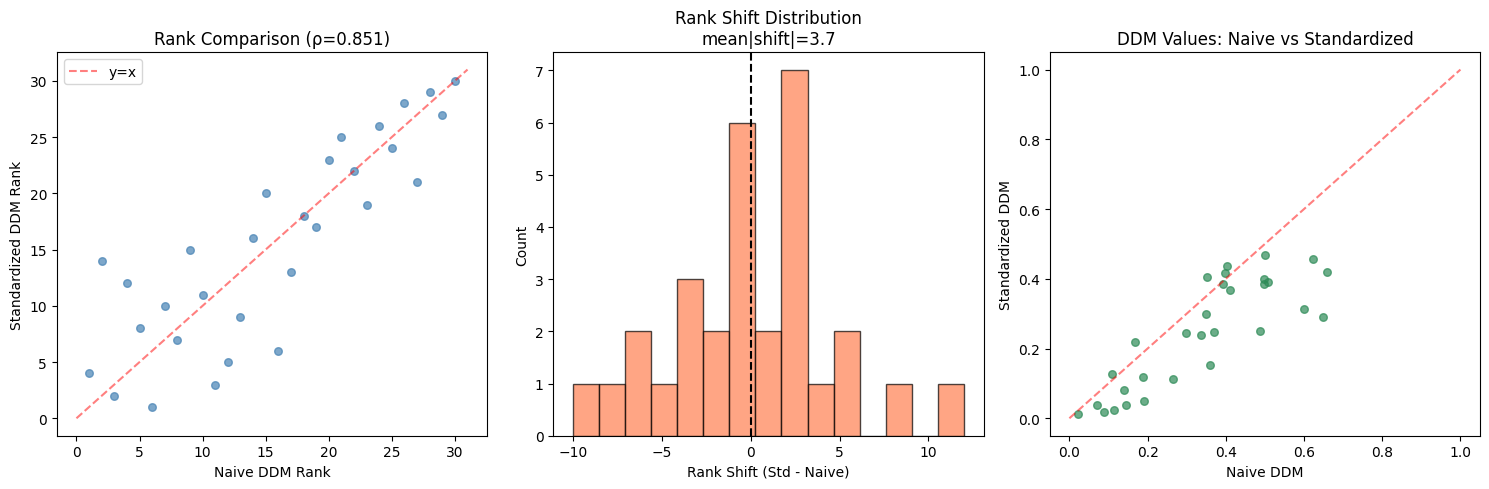

Saved ddm_rankings.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Naive vs Std rank scatter
ax = axes[0]
ax.scatter(naive_ranks, std_ranks, alpha=0.7, s=30, c='steelblue')
ax.plot([0, n+1], [0, n+1], 'r--', alpha=0.5, label='y=x')
ax.set_xlabel('Naive DDM Rank')
ax.set_ylabel('Standardized DDM Rank')
ax.set_title(f'Rank Comparison (ρ={rho:.3f})')
ax.legend()

# Plot 2: Rank shift distribution
ax = axes[1]
ax.hist(rank_shifts, bins=15, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Rank Shift (Std - Naive)')
ax.set_ylabel('Count')
ax.set_title(f'Rank Shift Distribution\nmean|shift|={mean_abs_shift:.1f}')

# Plot 3: Naive vs Std DDM values
ax = axes[2]
ax.scatter(naive_vals, std_vals, alpha=0.7, s=30, c='seagreen')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
ax.set_xlabel('Naive DDM')
ax.set_ylabel('Standardized DDM')
ax.set_title('DDM Values: Naive vs Standardized')

plt.tight_layout()
plt.savefig('ddm_rankings.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved ddm_rankings.png")